### Build a Basic Chatbot wiht Langgraph(GRAPH API)

In [21]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


In [ ]:
class State(TypedDict):
    messages:Annotated[list, add_messages]  # add_messages is a reduces which, do not reduce and replace the text intead it append(next)

graph_builder=StateGraph(State)

graph_builder

In [23]:
### LLM import and definition
import sys
sys.path.append("..")
from models import get_model

mli_model = get_model("mli")
llm  = mli_model

In [24]:
### Node Funtionalities
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}
    

In [25]:
graph_builder=StateGraph(State)

## Adding node in the Graph
graph_builder.add_node("chatbot", chatbot)

### Adding Edges in the graph
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

## compile the Graph

graph=graph_builder.compile()

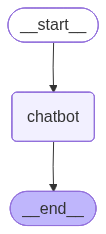

In [26]:
graph

In [27]:
response = graph.invoke({"messages":"hi"})

In [28]:
response["messages"][-1].content

'Hello! 👋 How can I assist you today?'

In [29]:
for event in graph.stream({"messages":"Hi, how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I’m doing great, thanks for asking. How can I help you today?


### Chatbot with Tool

In [30]:
from langchain_tavily import  TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("tell me about ashish singh working at dassault systemes and graduated from NIT rourkela in 2025")

{'query': 'tell me about ashish singh working at dassault systemes and graduated from NIT rourkela in 2025',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://in.linkedin.com/in/ashishsingh10',
   'title': 'Ashish Singh - Associate Software Engineer @ Dassault Systèmes | Knight @LeetCode | Full-Stack Developer(Java, MERN, Next.js) | UG EE’25 @NIT Rourkela | FFE Scholar',
   'content': 'Ashish Singh\nAssociate Software Engineer @ Dassault Systèmes | Knight @LeetCode | Full-Stack Developer(Java, MERN, Next.js) | UG EE’25 @NIT Rourkela | FFE Scholar\nIndia\n500 connections, 2711 followers\n\n\nAbout\nN/A\n\n\nExperience\nAssociate Software Engineer\n[Dassault Systèmes](https://fr.linkedin.com/company/dassaultsystemes?trk=public_profile_experience-group-header)\nJun 2025 - Present\nNone\n\n\nSoftware Engineer Intern\n[Dassault Systèmes](https://fr.linkedin.com/company/dassaultsystemes?trk=public_profile_experience-group-header)\nJan 2025 - Jun 2025

In [31]:
### Custom funtion

def multiply(a:int, b:int)->int:
    """Multiply a and b
    
    args:
        a (int): first int
        b (int): second int

    returns:
        int: _description output int
    """

In [32]:
tools = [tool, multiply]
llm_with_tools = llm.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatOpenAI(output_version=None, client=<openai.resources.chat.completions.completions.Completions object at 0x0000019CA8A09D30>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000019CA8A0A7B0>, root_client=<openai.OpenAI object at 0x0000019CA7EE1160>, root_async_client=<openai.AsyncOpenAI object at 0x0000019CA8A0A510>, model_name='openai/gpt-oss-120b', model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://euw1-devprol51-mlinference.3dx-staging.3ds.com/api/mli/v1', openai_proxy=None, http_client=<httpx.Client object at 0x0000019CA7C5EE40>, stream_chunk_timeout=120.0), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, 

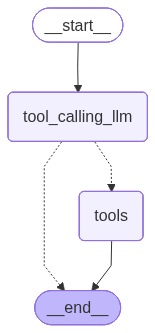

In [33]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

### Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    ## If the latest message (result) from assistnat is a tool call --> tools_condition routes to tools
    ### if the latest message (result) from assistent is not a tool call --> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", END)

graph=builder.compile()
graph

In [34]:
response = graph.invoke({"messages":"Give me recent todays news and multiply 5 with 10"})

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me recent todays news and multiply 5 with 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (chatcmpl-tool-84aebc00766c66e3)
 Call ID: chatcmpl-tool-84aebc00766c66e3
  Args:
    query: June 2 2026 news
    include_domains: []
    exclude_domains: []
    search_depth: basic
    include_images: False
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "June 2 2026 news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.modernghana.com/amp/videonews/658635", "title": "ABC News Live Prime: June 1, 2026 - Modern Ghana", "score": 0.9973888, "published_date": "Tue, 02 Jun 2026 04:30:00 GMT", "content": "More video News [...] President Trump claims talks with Iran continuing; man arrested for attempted break-in

### ReAct Agent Architecture

ReAct=Reason+Act

Before ReAct there was two main approaches: 

A. Chain of Thought(Reasoning only)
    Model thinks the steps

B. Tool Calling (Acting only)
    The Model directly calls the tools, gets results. It is good at fetching data but lacks planning. 

ReAct combines both: 
The model: 
1. Thinks
2. Uses tools
3. Observers results
4. Thinks again
5. Uses more tools if needed
6. Produces final answers


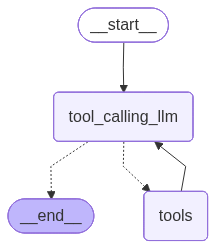

In [35]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

### Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    ## If the latest message (result) from assistnat is a tool call --> tools_condition routes to tools
    ### if the latest message (result) from assistent is not a tool call --> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

graph=builder.compile()
graph

In [37]:
response = graph.invoke({"messages":"Give me recent todays news and multiply 5 with 10"})

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me recent todays news and multiply 5 with 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (chatcmpl-tool-82fae3ef98a445d0)
 Call ID: chatcmpl-tool-82fae3ef98a445d0
  Args:
    query: June 2 2026 news
    include_domains: []
    exclude_domains: []
    search_depth: advanced
    include_images: False
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "June 2 2026 news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.modernghana.com/amp/videonews/658635", "title": "ABC News Live Prime: June 1, 2026 - Modern Ghana", "score": 0.9973888, "published_date": "Tue, 02 Jun 2026 04:30:00 GMT", "content": "More video News [...] President Trump claims talks with Iran continuing; man arrested for attempted break